# simulating band structure of square lattice of cylindrical pillars

In [2]:
import meep as mp
from meep import mpb
import meep.materials as materials

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as spo

import math

## realistic geometry
### sim

In [ ]:
num_bands = 5

k_points = [
    mp.Vector3(0,0,0),    # Gamma
    mp.Vector3(0.5,0,0),      # X
    mp.Vector3(0.5,0.5,0),    # M
    mp.Vector3(0,0,0)     # Gamma
]

k_points = mp.interpolate(40, k_points)

pp=1
sx=pp
sy=pp
pr=0.2


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    ),
    mp.Cylinder(
        material = mp.Medium(epsilon=1),
        height = 0.7, 
        radius = pr, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 10))

resolution = 50

ms = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

In [42]:
ms.run_tm()
tm_freqs = ms.all_freqs
tm_gaps = ms.gap_list
tm_first_gap = ms.retrieve_gap(1)

ms.run_te()
te_freqs = ms.all_freqs
te_gaps = ms.gap_list
te_first_gap = ms.retrieve_gap(1)
'''

def first_tm_gap(p):
    pp=p[0],
    pr=p[1],
    ms=mpb.ModeSolver(
        num_bands=1, 
        k_points=k_points,
        geometry=[
            mp.Cylinder(
                material = mp.Medium(index=3.67),
                height = mp.inf, 
                radius = pr, 
                axis = mp.Vector3(0,0,1), 
                center = mp.Vector3()
            )
        ],
        geometry_lattice=mp.Lattice(size = mp.Vector3(pp,pp,0)), 
        resolution=50
    )
    ms.run_tm()
    return -1 * ms.retrieve_gap(1)

result_tm = spo.minimize_scalar(first_tm_gap, [4,1])
print("d1 at max: {}".format(result_tm.x))
print(result_tm)
print("gap size at maximum: {}".format(result_tm.fun * -1))

def first_te_gap(p):
    pp=p[0],
    pr=p[1],
    ms=mpb.ModeSolver(
        num_bands=1, 
        k_points=k_points,
        geometry=[
            mp.Cylinder(
                material = mp.Medium(index=3.67),
                height = mp.inf, 
                radius = pr, 
                axis = mp.Vector3(0,0,1), 
                center = mp.Vector3()
            )
        ],
        geometry_lattice=mp.Lattice(size = mp.Vector3(pp,pp,0)), 
        resolution=50
    )
    ms.run_te()
    return -1 * ms.retrieve_gap(1)


result_te = spo.minimize_scalar(first_te_gap[4,1])

print("d1 at max tm: {}".format(result_tm.x))
print(result_tm)
print("tm gap size at maximum: {}".format(result_tm.fun * -1))
print("d1 at max te: {}".format(result_te.x))
print(result_te)
print("te gap size at maximum: {}".format(result_te.fun * -1))
'''

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 100 x 100 x 1000.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 10)
Cell volume = 10
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.2, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 19 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zodd.
Initializing fields to random numbers...
124 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.012195121951219513, 0.0, 0.0>
  Vector3<0.024390243902439025, 0.0, 0.0>
  Vector3<0.03658536585365854, 0.0, 0.0>
  Vector3<0.04878048780487805, 0.0, 0.0>
  Vector3<0.060975609756097

'\n\ndef first_tm_gap(p):\n    pp=p[0],\n    pr=p[1],\n    ms=mpb.ModeSolver(\n        num_bands=1, \n        k_points=k_points,\n        geometry=[\n            mp.Cylinder(\n                material = mp.Medium(index=3.67),\n                height = mp.inf, \n                radius = pr, \n                axis = mp.Vector3(0,0,1), \n                center = mp.Vector3()\n            )\n        ],\n        geometry_lattice=mp.Lattice(size = mp.Vector3(pp,pp,0)), \n        resolution=50\n    )\n    ms.run_tm()\n    return -1 * ms.retrieve_gap(1)\n\nresult_tm = spo.minimize_scalar(first_tm_gap, [4,1])\nprint("d1 at max: {}".format(result_tm.x))\nprint(result_tm)\nprint("gap size at maximum: {}".format(result_tm.fun * -1))\n\ndef first_te_gap(p):\n    pp=p[0],\n    pr=p[1],\n    ms=mpb.ModeSolver(\n        num_bands=1, \n        k_points=k_points,\n        geometry=[\n            mp.Cylinder(\n                material = mp.Medium(index=3.67),\n                height = mp.inf, \n         

### plot

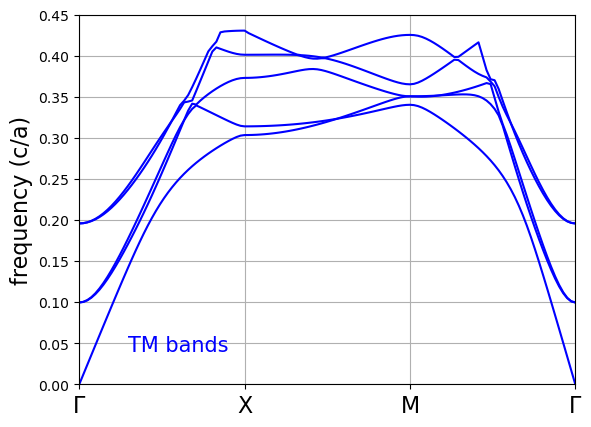

-110.8838328887167

In [43]:
fig, ax = plt.subplots()
x = range(len(tm_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
ax.plot(tm_freqs, color='blue')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in tm_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)

points_in_between = (len(tm_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.45])

plt.show()

te_first_gap



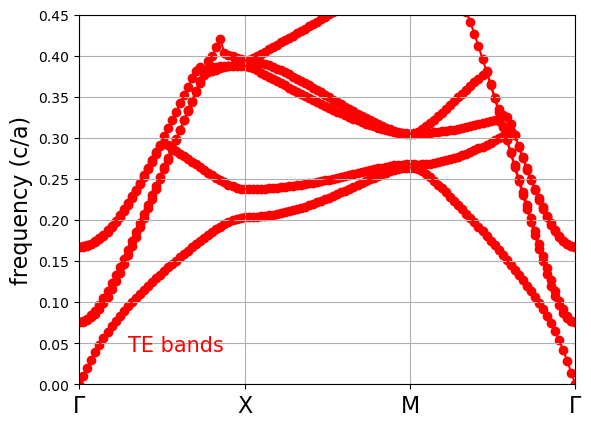

In [44]:
fig, ax = plt.subplots()
x = range(len(te_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tez in zip(x, te_freqs):
    ax.scatter([xz]*len(tez), tez, color='red')
ax.plot(te_freqs, color='red')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='red', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TE bands', color='red', size=15)

points_in_between = (len(te_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.45])
plt.show()

In [49]:
num_bands = 5

k_points = [
    mp.Vector3(0,0,0),    # Gamma
    mp.Vector3(0.5,0,0),      # X
    mp.Vector3(0.5,0.5,0),    # M
    mp.Vector3(0,0,0)     # Gamma
]

k_points = mp.interpolate(10, k_points)

pp=1
sx=pp
sy=pp
pr=0.2


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 20))

resolution = 40

ms = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

In [ ]:
ms.run_zeven()
even_freqs = ms.all_freqs
even_gaps = ms.gap_list
even_first_gap = ms.retrieve_gap(1)

ms.run_zodd()
odd_freqs = ms.all_freqs
odd_gaps = ms.gap_list
odd_first_gap = ms.retrieve_gap(1)



Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 40 x 40 x 800.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 3 and 16 object nodes (vs. 1 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.045454545454545456, 0.0, 0.0>
  Vector3<0.09090909090909091, 0.0, 0.0>
  Vector3<0.13636363636363635, 0.0, 0.0>
  Vector3<0.18181818181818182, 0.0, 0.0>
  Vector3<0.2272727272727273, 0.0, 0.0>
  Vector3<0.2727272727272727, 0.0, 0.0>
  Vector3<0.3181818181818182, 0

In [51]:
ms.run_yeven()
y_even_freqs = ms.all_freqs
y_even_gaps = ms.gap_list
y_even_first_gap = ms.retrieve_gap(1)

ms.run_yodd()
y_odd_freqs = ms.all_freqs
y_odd_gaps = ms.gap_list
y_odd_first_gap = ms.retrieve_gap(1)

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 40 x 40 x 800.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometric object tree has depth 3 and 16 object nodes (vs. 1 actual objects)
Initializing epsilon function...
Solving for band polarization: yeven.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.045454545454545456, 0.0, 0.0>
  Vector3<0.09090909090909091, 0.0, 0.0>
  Vector3<0.13636363636363635, 0.0, 0.0>
  Vector3<0.18181818181818182, 0.0, 0.0>
  Vector3<0.2272727272727273, 0.0, 0.0>
  Vector3<0.2727272727272727, 0.0, 0.0>
  Vector3<0.3181818181818182, 0.0, 0.0>
  Vector3<0.

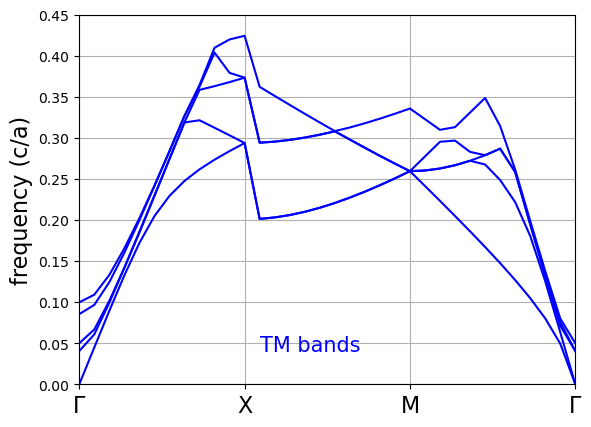

-200.0

In [53]:
fig, ax = plt.subplots()
x = range(len(y_even_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
ax.plot(y_even_freqs, color='blue')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in y_even_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)

points_in_between = (len(y_even_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.45])

plt.show()

y_even_first_gap



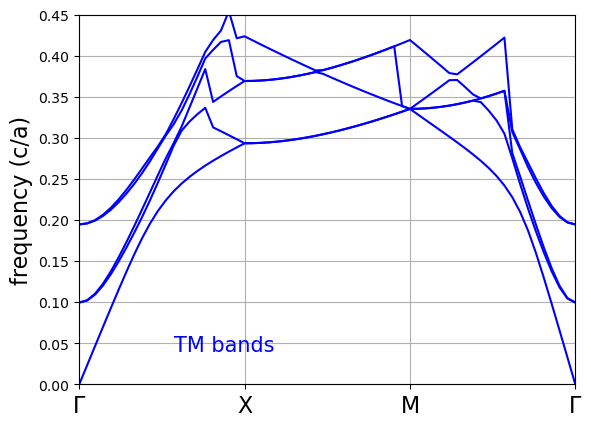

-108.45912235268143

In [48]:
fig, ax = plt.subplots()
x = range(len(odd_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
ax.plot(odd_freqs, color='blue')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in odd_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)

points_in_between = (len(odd_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.45])

plt.show()

odd_first_gap



## infinite rods, static index
### sim

In [ ]:
num_bands = 10

k_points_gg = [
    mp.Vector3(0,0,0.5),    # "Gamma"
    mp.Vector3(0,0,0),      # Gamma
    #mp.Vector3(0.5,0,0),    # X
   # mp.Vector3(0,0,0.5)     # "Gamma"
]

k_points_gx = [
    #mp.Vector3(0,0,0.5),    # "Gamma"
    mp.Vector3(0,0,0),      # Gamma
    mp.Vector3(0.5,0,0),    # X
   # mp.Vector3(0,0,0.5)     # "Gamma"
]

k_points_gg = mp.interpolate(10, k_points_gg)
k_points_gx = mp.interpolate(10,k_points_gx)

geometry = [
    mp.Cylinder(
        radius = 0.14, 
        material = mp.Medium(index = 3.67)
    )
]

default_material = mp.Medium(index = 1.45)

geometry_lattice = mp.Lattice(size = mp.Vector3(0.6, 0.6))

resolution = 150

ms_gg_2 = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points_gg,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    default_material=default_material,
                    resolution=resolution)

ms_gx_2 = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points_gx,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    default_material=default_material,
                    resolution=resolution)

In [ ]:
ms_gg_2.run_tm()
tm_freqs_gg_2 = ms_gg.all_freqs

ms_gx_2.run_tm()
tm_freqs_gx_2 = ms_gx.all_freqs

Initializing eigensolver data
Computing 10 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 90 x 90 x 1.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (0.6, 0, 0)
     (0, 0.6, 0)
     (0, 0, 1)
Cell volume = 0.36
Reciprocal lattice vectors (/ 2 pi):
     (1.66667, -0, 0)
     (-0, 1.66667, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0,0,0)
          radius 0.14, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 1 and 1 object nodes (vs. 1 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: tm.
Initializing fields to random numbers...
12 k-points
  Vector3<0.0, 0.0, 0.5>
  Vector3<0.0, 0.0, 0.45454545454545453>
  Vector3<0.0, 0.0, 0.40909090909090906>
  Vector3<0.0, 0.0, 0.36363636363636365>
  Vector3<0.0, 0.0, 0.3181818181818182>
  Vector3<0.0, 0.0, 0.2727272727272727>
  Vector3<0.0, 0.0, 0.2272727272727273>
  Vector3<0.0, 0.0, 0.181818181818

### plot

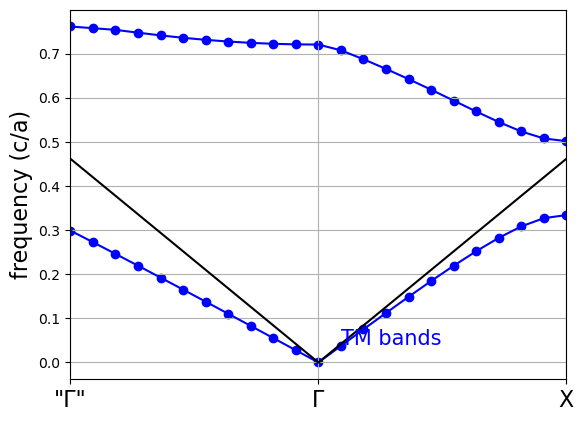

In [ ]:
fig, ax = plt.subplots()


tm_freqs_gg_trial = tm_freqs_gg_2[0:11, [0,2]]
tm_freqs_gx_trial = tm_freqs_gx_2[0:12,[0,1]]
light_line  = np.abs(np.linspace(-1.45/np.pi,1.45/np.pi,23))

tm_freqs_trial=np.concatenate([tm_freqs_gg_trial, tm_freqs_gx_trial])

x = range(len(tm_freqs_trial))

# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tmz in zip(x, tm_freqs_trial):
    ax.scatter([xz]*len(tmz), tmz, color='blue')
ax.plot(tm_freqs_trial, color='blue')
ax.plot(light_line, color = "black")
ax.set_xlim([x[0], x[-1]])

# Plot gaps
'''for gap in tm_gaps_1:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)
'''

# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)

points_in_between = (len(tm_freqs_trial) - 3) / 2
tick_locs = [i*points_in_between+i for i in range(3)]
tick_labs = ['"Γ"', 'Γ', 'X']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)

plt.show()

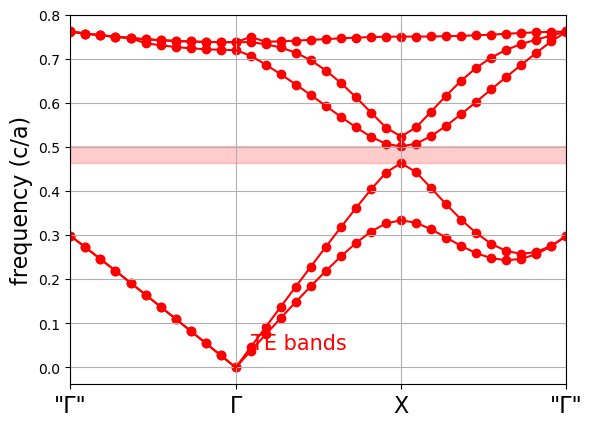

In [ ]:
fig, ax = plt.subplots()
x = range(len(te_freqs_2))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tez in zip(x, te_freqs_2):
    ax.scatter([xz]*len(tez), tez, color='red')
ax.plot(te_freqs_2, color='red')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps_2:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='red', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TE bands', color='red', size=15)

points_in_between = (len(te_freqs_2) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['"Γ"', 'Γ', 'X', '"Γ"']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)

plt.show()

## infinite rods, dispersion materials (glass and silicon only)
### sim

In [ ]:
num_bands = 10

k_points = [          # Gamma
    mp.Vector3(0,0,0.5),        # X
    mp.Vector3(0.5, 0, 0)           # Gamma
]

k_points = mp.interpolate(5, k_points)

geometry = [
    mp.Cylinder(
        radius = 0.14, 
        material = materials.aSi
    )
]

default_material = materials.fused_quartz

geometry_lattice = mp.Lattice(size = mp.Vector3(0.6, 0.6))

resolution = 100

ms = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    default_material=default_material,
                    resolution=resolution)

In [ ]:
ms.run_tm()
tm_freqs_3 = ms.all_freqs
tm_gaps_3 = ms.gap_list
ms.run_te()
te_freqs_3 = ms.all_freqs
te_gaps_3 = ms.gap_list

Initializing eigensolver data
Computing 10 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 60 x 60 x 1.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (0.6, 0, 0)
     (0, 0.6, 0)
     (0, 0, 1)
Cell volume = 0.36
Reciprocal lattice vectors (/ 2 pi):
     (1.66667, -0, 0)
     (-0, 1.66667, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0,0,0)
          radius 0.14, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 1 and 1 object nodes (vs. 1 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: tm.
Initializing fields to random numbers...
7 k-points
  Vector3<0.0, 0.0, 0.5>
  Vector3<0.08333333333333333, 0.0, 0.4166666666666667>
  Vector3<0.16666666666666666, 0.0, 0.33333333333333337>
  Vector3<0.25, 0.0, 0.25>
  Vector3<0.3333333333333333, 0.0, 0.16666666666666669>
  Vector3<0.41666666666666663, 0.0, 0.08333333333333337>
  Vector3<0.5, 0.0, 0.0>


### plots

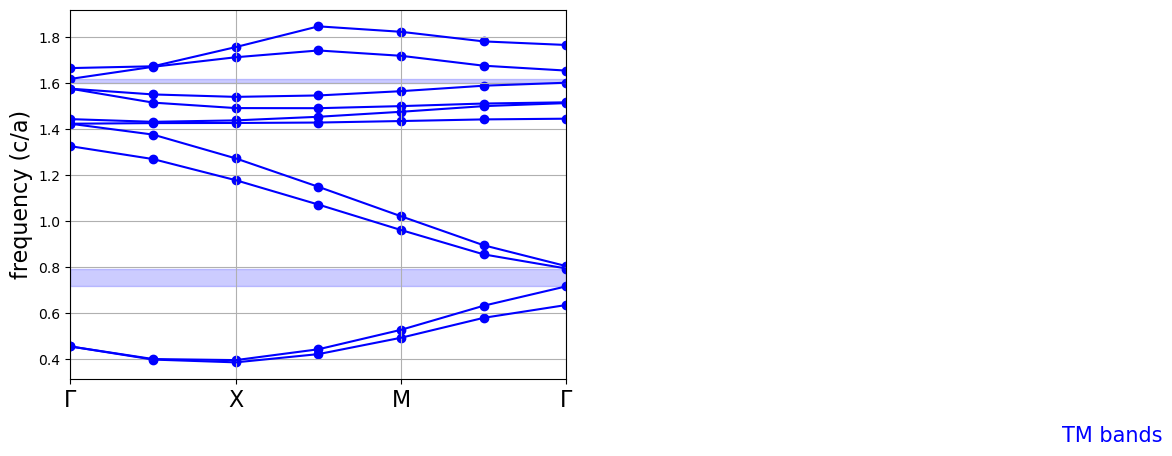

In [ ]:
fig, ax = plt.subplots()
x = range(len(tm_freqs_3))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tmz in zip(x, tm_freqs_3):
    ax.scatter([xz]*len(tmz), tmz, color='blue')
ax.plot(tm_freqs_3, color='blue')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in tm_gaps_3:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)

points_in_between = (len(tm_freqs_3) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)

plt.show()

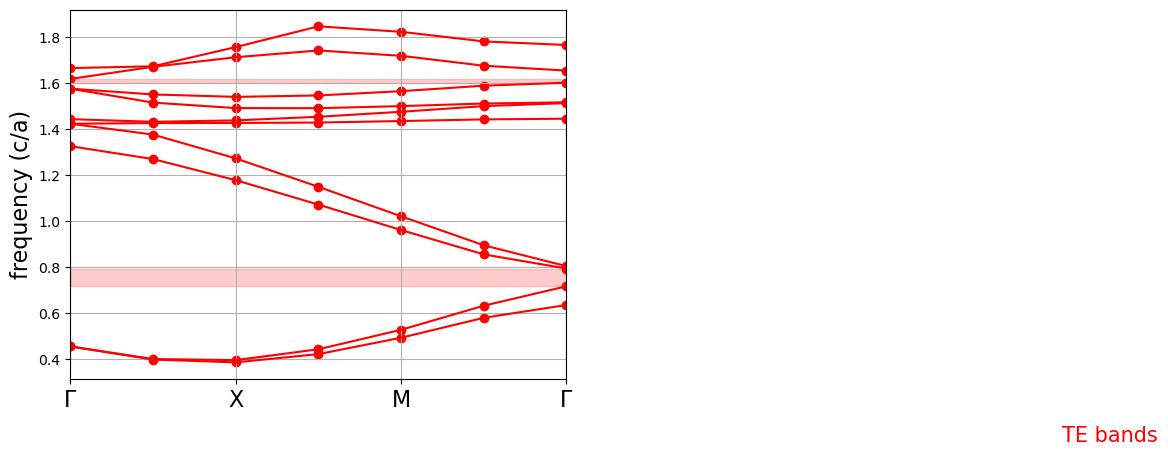

In [ ]:
fig, ax = plt.subplots()
x = range(len(te_freqs_3))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tez in zip(x, te_freqs_3):
    ax.scatter([xz]*len(tez), tez, color='red')
ax.plot(te_freqs_3, color='red')
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps_3:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='red', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TE bands', color='red', size=15)

points_in_between = (len(te_freqs_3) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)

plt.show()

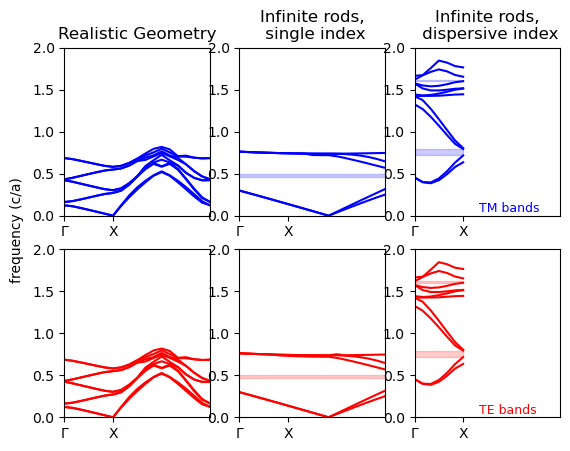

In [ ]:
fig2, axes = plt.subplots(2, 3)

x = range(len(tm_freqs_1))
# Plot bands

axes[0,0].plot(tm_freqs_1, color='blue')
axes[0,0].set_xlim([x[0], x[-1]])
axes[0,0].set_ylim([0, 2])

# Plot gaps
for gap in tm_gaps_1:
    if gap[0] > 0.5:
        axes[0,0].fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)

x = range(len(tm_freqs_2))
# Plot bands

axes[0,1].plot(tm_freqs_2, color='blue')
axes[0,1].set_xlim([x[0], x[-1]])

# Plot gaps
for gap in tm_gaps_2:
    if gap[0] > 0.5:
        axes[0,1].fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)

x = range(len(tm_freqs_3))
# Plot bands

axes[0,2].plot(tm_freqs_3, color='blue')
axes[0,2].set_xlim([x[0], x[-1]])

# Plot gaps
for gap in tm_gaps_3:
    if gap[0] > 0.5:
        axes[0,2].fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)

x = range(len(te_freqs_1))
# Plot bands

axes[1,0].plot(te_freqs_1, color='red')
axes[1,0].set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps_1:
    if gap[0] > 0.5:
        axes[1,0].fill_between(x, gap[1], gap[2], color='red', alpha=0.2)

x = range(len(te_freqs_2))
# Plot bands

axes[1,1].plot(te_freqs_2, color='red')
axes[1,1].set_xlim([x[0], x[-1]])


# Plot gaps
for gap in te_gaps_2:
    if gap[0] > 0.5:
        axes[1,1].fill_between(x, gap[1], gap[2], color='red', alpha=0.2)

x = range(len(te_freqs_3))
# Plot bands

axes[1,2].plot(te_freqs_3, color='red')
axes[1,2].set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps_3:
    if gap[0] > 0.5:
        axes[1,2].fill_between(x, gap[1], gap[2], color='red', alpha=0.2)


# Plot labels
axes[1,2].text(8, 0.04, 'TE bands', color='red', size=9)
axes[0,2].text(8, 0.04, 'TM bands', color='blue', size=9)

points_in_between = (len(te_freqs_3) - 2) / 1
tick_locs = [i*points_in_between+i for i in range(2)]
tick_labs = ['Γ', 'X']
axes[0,0].set_xticks(tick_locs)
axes[0,0].set_xticklabels(tick_labs, size=10)
axes[0,0].set_title("Realistic Geometry")
axes[0,1].sharex(axes[0,0])
axes[0,1].sharey(axes[0,0])
axes[0,1].set_title("Infinite rods,\n single index")
axes[0,2].sharex(axes[0,0])
axes[0,2].sharey(axes[0,0])
axes[0,2].set_title("Infinite rods,\n dispersive index")
axes[1,0].sharex(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharex(axes[0,0])
axes[1,1].sharey(axes[0,0])
axes[1,2].sharex(axes[0,0])
axes[1,2].sharey(axes[0,0])
fig2.text(0.04, 0.5, 'frequency (c/a)', va='center', rotation='vertical')
ax.grid(True)

plt.show()

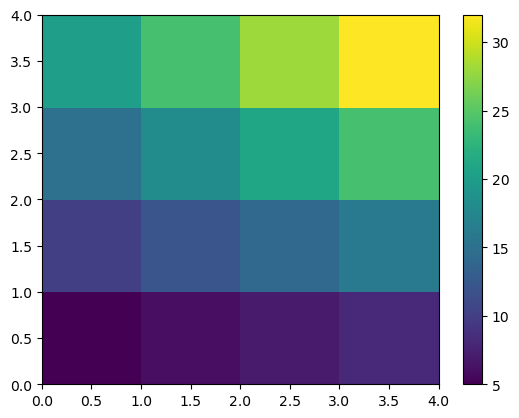

In [ ]:
n = [1, 2, 3, 4]
m = [5, 6, 7, 8]
o = np.empty([4,4])

for i in range(len(n)):
    for j in range(len(m)):
        o[i,j] = n[i] * m[j]

guh, grr = plt.subplots()
gar = grr.pcolor(o)
guh.colorbar(gar)


# Recreating Fan paper

## 2d

### setup

In [15]:
num_bands = 5

k_points = [
    mp.Vector3(0,0,0),    # Gamma
    mp.Vector3(0.5,0,0),      # X
    mp.Vector3(0.5,0.5,0),    # M
    mp.Vector3(0,0,0)     # Gamma
]

k_points = mp.interpolate(10, k_points)

pp=1
sx=pp
sy=pp
pr=0.2


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    ),
    mp.Cylinder(
        material = mp.Medium(epsilon=1),
        height = 0.7, 
        radius = 0, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 0))

resolution = 40

ms_2d = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

### run

In [16]:
ms_2d.run_zeven()
zeven_freqs = ms_2d.all_freqs
zeven_gaps = ms_2d.gap_list
zeven_first_gap = ms_2d.retrieve_gap(1)

ms_2d.run_zodd()
zodd_freqs = ms_2d.all_freqs
zodd_gaps = ms_2d.gap_list
zodd_first_gap = ms_2d.retrieve_gap(1)

ms_2d.run_yeven()
yeven_freqs = ms_2d.all_freqs
yeven_gaps = ms_2d.gap_list
yeven_first_gap = ms_2d.retrieve_gap(1)

ms_2d.run_yodd()
yodd_freqs = ms_2d.all_freqs
yodd_gaps = ms_2d.gap_list
yodd_first_gap = ms_2d.retrieve_gap(1)

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 40 x 40 x 1.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 28 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.045454545454545456, 0.0, 0.0>
  Vector3<0.09090909090909091, 0.0, 0.0>
  Vector3<0.13636363636363635, 0.0, 0.0>
  Vector3<0.18181818181818182, 0.0, 0.0>
  Vector3<0.2272727272727273, 0.0, 0.0>
  

### plot

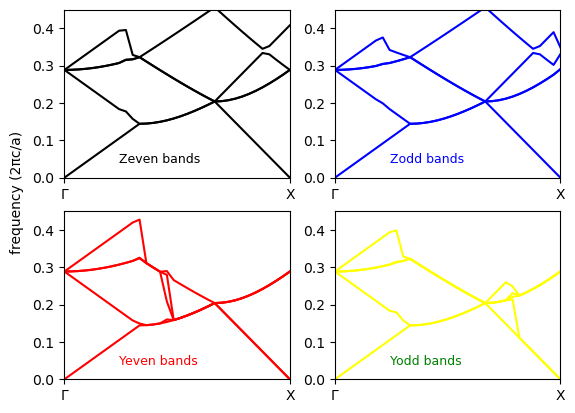

In [17]:
fig2, axes = plt.subplots(2, 2)

x = range(len(zeven_freqs))
# Plot bands

axes[0,0].plot(zeven_freqs, color = "black")
axes[0,0].set_xlim([x[0], x[-1]])
axes[0,0].set_ylim([0, 0.45])


x = range(len(zodd_freqs))
# Plot bands

axes[0,1].plot(zodd_freqs, color='blue')
axes[0,1].set_xlim([x[0], x[-1]])

x = range(len(yeven_freqs))
# Plot bands

axes[1,0].plot(yeven_freqs, color='red')
axes[1,0].set_xlim([x[0], x[-1]])

x = range(len(yodd_freqs))
# Plot bands

axes[1,1].plot(yodd_freqs, color='yellow')
axes[1,1].set_xlim([x[0], x[-1]])

# Plot labels
axes[0,0].text(8, 0.04, 'Zeven bands', color='black', size=9)
axes[0,1].text(8, 0.04, 'Zodd bands', color='blue', size=9)
axes[1,0].text(8, 0.04, 'Yeven bands', color='red', size=9)
axes[1,1].text(8, 0.04, 'Yodd bands', color='green', size=9)

points_in_between = (len(zeven_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(2)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
axes[0,0].set_xticks(tick_locs)
axes[0,0].set_xticklabels(tick_labs, size=10)
axes[0,1].sharex(axes[0,0])
axes[0,1].sharey(axes[0,0])
axes[1,0].sharex(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharex(axes[0,0])
axes[1,1].sharey(axes[0,0])
fig2.text(0.04, 0.5, 'frequency (2\u03c0c/a)', va='center', rotation='vertical')

plt.show()

## 3d

### setup

In [ ]:
num_bands = 1

k_points = [
    mp.Vector3(0,0,0),    # Gamma
    mp.Vector3(0.5,0,0),      # X
    mp.Vector3(1,0,0),      # Gamma'
    mp.Vector3(1.5,0)
    mp.Vector3(2,0.5,0),    # M
    mp.Vector3(0,0,0)     # Gamma
]

k_points = mp.interpolate(10, k_points)

pp=1
sx=pp
sy=pp
pr=0.2


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    ),
    mp.Cylinder(
        material = mp.Medium(epsilon=1),
        height = 0.7, 
        radius = 0, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 20))

resolution = 40

ms_3d = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

### run

In [21]:
ms_3d.run_zeven()
zeven_freqs = ms_3d.all_freqs
zeven_gaps = ms_3d.gap_list
zeven_first_gap = ms_3d.retrieve_gap(1)

ms_3d.run_zodd()
zodd_freqs = ms_3d.all_freqs
zodd_gaps = ms_3d.gap_list
zodd_first_gap = ms_3d.retrieve_gap(1)

ms_3d.run_yeven()
yeven_freqs = ms_3d.all_freqs
yeven_gaps = ms_3d.gap_list
yeven_first_gap = ms_3d.retrieve_gap(1)

ms_3d.run_yodd()
yodd_freqs = ms_3d.all_freqs
yodd_gaps = ms_3d.gap_list
yodd_first_gap = ms_3d.retrieve_gap(1)

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 40 x 40 x 800.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 28 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Solving for band polarization: zeven.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.045454545454545456, 0.0, 0.0>
  Vector3<0.09090909090909091, 0.0, 0.0>
  Vector3<0.13636363636363635, 0.0, 0.0>
  Vector3<0.18181818181818182, 0.0, 0.0>
  Vector3<0.2272727272727273, 0.0, 0.0>
  Vector3<0.2

### plot

In [ ]:
zeven_freqs

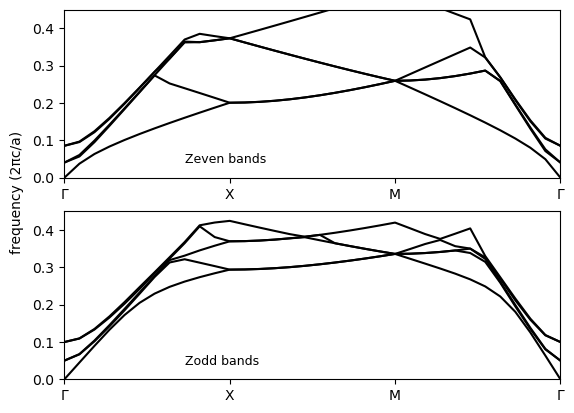

In [88]:
fig2, axes = plt.subplots(2, 1)

x = range(len(zeven_freqs))
# Plot bands

axes[0].plot(zeven_freqs, color = "black")
axes[0].set_xlim([x[0], x[-1]])
axes[0].set_ylim([0, 0.45])


x = range(len(zodd_freqs))
# Plot bands

axes[1].plot(zodd_freqs, color='black')
axes[1].set_xlim([x[0], x[-1]])
# Plot labels
axes[0].text(8, 0.04, 'Zeven bands', color='black', size=9)
axes[1].text(8, 0.04, 'Zodd bands', color='black', size=9)

points_in_between = (len(zeven_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
axes[0].set_xticks(tick_locs)
axes[0].set_xticklabels(tick_labs, size=10)
axes[1].sharex(axes[0])
axes[1].sharey(axes[0])
fig2.text(0.04, 0.5, 'frequency (2\u03c0c/a)', va='center', rotation='vertical')

plt.show()

## 3d holes

### setup

In [25]:
num_bands = 10

k_points = [
    mp.Vector3(0,0,0),    # Gamma
    mp.Vector3(0.5,0,0)
]

k_points = mp.interpolate(98, k_points)

pp=1
sx=pp
sy=pp
pr=0.2


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    ),
    mp.Cylinder(
        material = mp.Medium(epsilon=1),
        height = 0.7, 
        radius = 0, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 20))

resolution = 30

ms_3d_holes = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

### run

In [26]:
ms_3d_holes.run_zodd()
hole_freqs = ms_3d_holes.all_freqs
#hole_gaps = ms_3d_holes.gap_list
#hole_first_gap = ms_3d_holes.retrieve_gap(1)

Initializing eigensolver data
Computing 10 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 30 x 30 x 600.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 28 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zodd.
Initializing fields to random numbers...
100 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.005050505050505051, 0.0, 0.0>
  Vector3<0.010101010101010102, 0.0, 0.0>
  Vector3<0.015151515151515152, 0.0, 0.0>
  Vector3<0.020202020202020204, 0.0, 0.0>
  Vector3<0.025252525252525

### plot single period

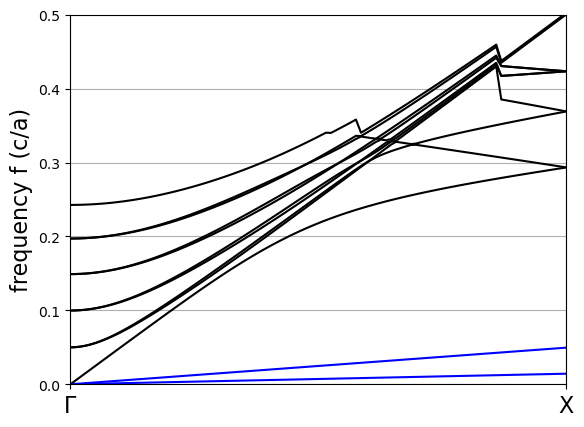

In [28]:
fig, ax = plt.subplots()
x = range(len(hole_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
ax.plot(hole_freqs, color='black')
ax.set_xlim([x[0], x[-1]])



# Plot labels

points_in_between = (len(hole_freqs) - 2) / 1
tick_locs = [i*points_in_between+i for i in range(2)]
tick_labs = ['Γ', 'X']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency f (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.5])

ax.plot(np.linspace(0,0.5,1000), color = 'blue')
ax.plot(np.linspace(0,0.5,1000)/np.sqrt(12), color = 'blue')

plt.show()



### plot equivalent double period

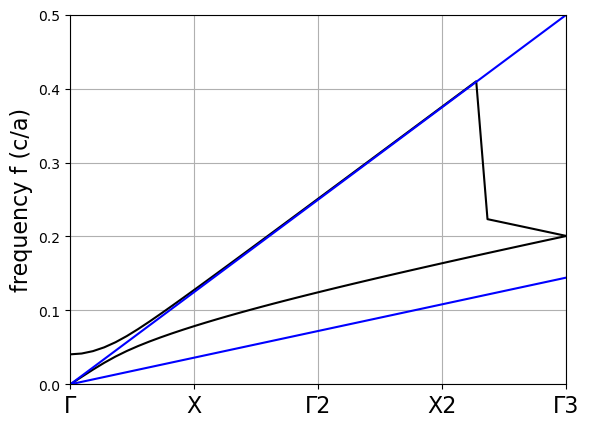

In [10]:
fig, ax = plt.subplots()
x = range(len(hole_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
ax.plot(hole_freqs, color='black')
ax.set_xlim([x[0], x[-1]])



# Plot labels

points_in_between = (len(hole_freqs) - 5) / 4
tick_locs = [i*points_in_between+i for i in range(5)]
tick_labs = ['Γ', 'X', 'Γ2', 'X2', 'Γ3']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency f (c/a)', size=16)
ax.grid(True)
ax.set_ylim([0, 0.5])

ax.plot(np.linspace(0,0.5,45), color = 'blue')
ax.plot(np.linspace(0,0.5,45)/np.sqrt(12), color = 'blue')

plt.show()

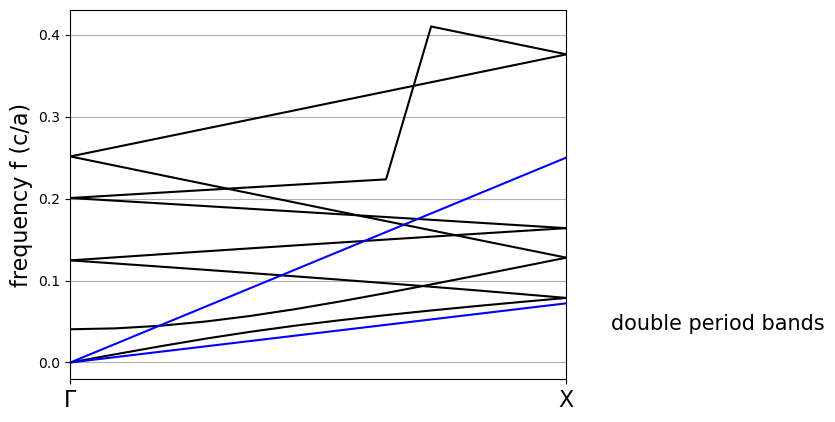

In [11]:
fig, ax = plt.subplots()
x = range(len(hole_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
#for xz, tez in zip(x, tm_freqs):
#    ax.scatter([xz]*len(tez), tez, color='blue')
band_1=hole_freqs[0:12]
band_2=list(reversed(hole_freqs[11:23]))
band_3=hole_freqs[22:34]
band_4=list(reversed(hole_freqs[33:45]))
ax.plot(band_1, color='black')
ax.plot(band_2, color='black')
ax.plot(band_3, color='black')
ax.plot(band_4, color='black')
ax.set_xlim([0, 10])



# Plot labels
ax.text(12, 0.04, 'double period bands', color='black', size=15)

points_in_between = (len(band_1) - 2) / 1
tick_locs = [i*points_in_between+i for i in range(2)]
tick_labs = ['Γ', 'X']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency f (c/a)', size=16)
ax.grid(True)
#ax.set_ylim([0, 0.5])

ax.plot(np.linspace(0,0.25,12), color = 'blue')
ax.plot(np.linspace(0,0.25,12)/np.sqrt(12), color = 'blue')

plt.show()



In [44]:
efields = []

def get_efields(ms, band):
    efields.append(ms.get_efield(band, bloch_phase=True))

ms_3d_holes.run_zeven(mpb.output_at_kpoint(mp.Vector3(0,0,0), mpb.fix_efield_phase,
          get_efields, mpb.output_efield_y))

# Create an MPBData instance to transform the efields
md = mpb.MPBData(rectify=True, resolution=30, periods=3)



Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 30 x 30 x 600.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 28 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Solving for band polarization: zeven.
Initializing fields to random numbers...
45 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.011363636363636364, 0.0, 0.0>
  Vector3<0.022727272727272728, 0.0, 0.0>
  Vector3<0.03409090909090909, 0.0, 0.0>
  Vector3<0.045454545454545456, 0.0, 0.0>
  Vector3<0.05681818181818182, 0.0, 0.0>
  Vector3<

real part range: 0 .. 0
imag part range: 0 .. 0
real part range: -8.81191e-08 .. 8.64559e-08
imag part range: -9.96293e-08 .. 1.04362e-07


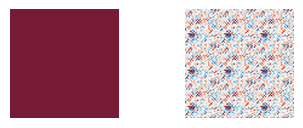

In [59]:


converted = []
for f in efields:
    # Get just the z component of the efields
    f = f[..., 3,2]
    converted.append(md.convert(f))

for i, f in enumerate(converted):
    plt.subplot(331 + i)
    #plt.contour(converted_eps.T, cmap='binary')
    plt.imshow(np.real(f).T, interpolation='spline36', cmap='RdBu', alpha=0.9)
    plt.axis('off')

plt.show()

In [3]:
num_bands = 40

k_points = [
    mp.Vector3(0.006122,0,0)
]

#k_points = mp.interpolate(, k_points)

pp=1
sx=pp
sy=pp
pr=0.255814


default_material=mp.Medium(epsilon=1)

geometry = [
    mp.Block(
        material = mp.Medium(epsilon=12), 
        size=mp.Vector3(sx,sy,0.5),
        center=mp.Vector3()
    ),
    mp.Cylinder(
        material = mp.Medium(epsilon=1),
        height = 0.7, 
        radius = pr, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


geometry_lattice = mp.Lattice(size = mp.Vector3(sx, sx, 20))

resolution = 40

ms_3d_test = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    resolution=resolution)

In [4]:
ms_3d_test.run_zodd(mpb.fix_efield_phase)
test_freqs = ms_3d_test.all_freqs

Initializing eigensolver data
Computing 40 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 40 x 40 x 800.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 20)
Cell volume = 20
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 0.05)
Geometric objects:
     block, center = (0,0,0)
          size (1,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.255814, height 0.7, axis (0, 0, 1)
Geometric object tree has depth 4 and 19 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zodd.
Initializing fields to random numbers...
1 k-points
  Vector3<0.006122, 0.0, 0.0>
elapsed time for initialization: 1.6019599437713623
solve_kpoint (0.006122,0,0):
zoddfreqs:, k index, k1, k2, k3, kmag/2pi, zodd band 1, zodd band 2, zodd band 3, zodd band 4, zodd band

2.2346517011779423
2.2346517011779423



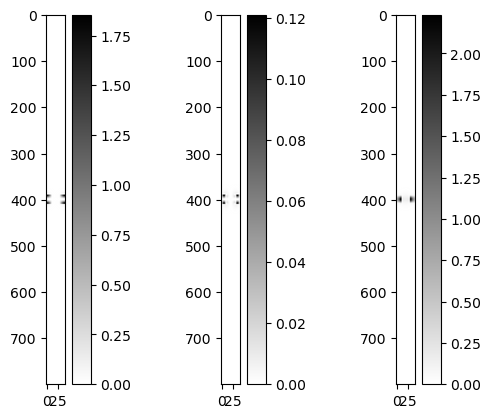

In [29]:
band=1+22

d=ms_3d_test.get_dfield(band)
e=np.conjugate(ms_3d_test.get_efield(band))

u=np.multiply(d,e)

grxh = u[15].transpose()[0]
gryh = u[15].transpose()[1]
grzh = u[15].transpose()[2]

fig,ax = plt.subplots(1,3)

ax_1=ax[0].imshow(np.abs(grxh), cmap="binary", interpolation="spline36")
ax_2=ax[1].imshow(np.abs(gryh), cmap="binary", interpolation="spline36")
ax_3=ax[2].imshow(np.abs(grzh), cmap="binary", interpolation="spline36")

fig.colorbar(mappable=ax_1)
fig.colorbar(mappable=ax_2)
fig.colorbar(mappable=ax_3)

print(np.amax(np.real(grzh)))
print(np.amax(np.real([grxh,gryh,grzh])))
print()


In [28]:
mode_0=[np.inf]*40

for i in range(40):
    
    d_=ms_3d_test.get_dfield(i+1)
    e_=np.conjugate(ms_3d_test.get_efield(i+1))

    u_=np.multiply(d_,e_)
    if i+1==1:
        mode_0[i]=1
    else:
        if 500*np.max(np.abs(u_[0:40,0:40,0:350]))< np.max(np.abs(u_[0:40,0:40,383:413])):
            mode_0[i]=1
mode_0


[1,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 1,
 inf,
 inf,
 inf,
 inf,
 1,
 inf,
 inf,
 1,
 1,
 inf,
 inf,
 1,
 1,
 1,
 inf,
 inf,
 inf,
 inf,
 1,
 inf,
 inf,
 1]

In [21]:
grah=np.multiply(test_freqs,mode_0)
grah
test_freqs

array([[0.00605548, 0.05033604, 0.05035231, 0.10000084, 0.10000932,
        0.14945297, 0.14945897, 0.19823672, 0.19824152, 0.24554165,
        0.24554054, 0.2898296 , 0.28983163, 0.33061018, 0.33061149,
        0.37206317, 0.37206448, 0.41417955, 0.41523386, 0.41545308,
        0.42536115, 0.42536792, 0.44217605, 0.46587762, 0.46587985,
        0.50403167, 0.5106029 , 0.51353176, 0.51357923, 0.5234762 ,
        0.52338379, 0.55561188, 0.55989631, 0.55995224, 0.57117423,
        0.57120221, 0.60427227, 0.61446069, 0.61446137, 0.63722419]])

In [8]:
np.sort(grah)

array([[0.00494232, 0.39587196, 0.39697696, 0.39697699, 0.39807805,
        0.4862718 , 0.48744817, 0.48744831, 0.48861923, 0.49247122,
        0.49247157, 0.49418992, 0.49419017, 0.585208  , 0.58520802,
        0.58691752,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf]])

In [488]:
a = [[1,2,3]]
b=[[4,5,6]]
c=[[7,8,9]]
d=np.concatenate((a,b), axis = 0)

np.concatenate((d,c), axis = 0).transpose()

array([[1, 4, 7],
       [2, 5, 8],
       [3, 6, 9]])

0.8264472609662399
2.412082054499392



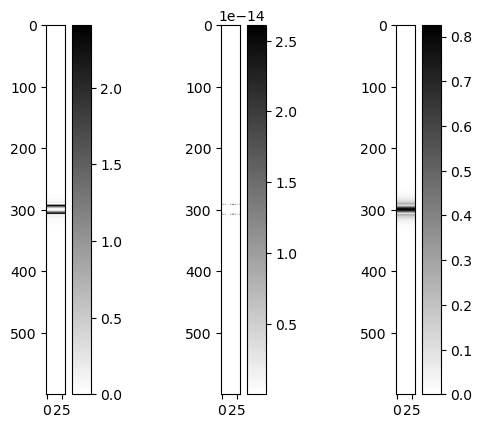

In [34]:
band=1+0

d=ms_3d_holes.get_dfield(band)
e=np.conjugate(ms_3d_holes.get_efield(band))

u=np.multiply(d,e)

grxh = u[15].transpose()[0]
gryh = u[15].transpose()[1]
grzh = u[15].transpose()[2]

fig,ax = plt.subplots(1,3)

ax_1=ax[0].imshow(np.abs(grxh), cmap="binary", interpolation="spline36")
ax_2=ax[1].imshow(np.abs(gryh), cmap="binary", interpolation="spline36")
ax_3=ax[2].imshow(np.abs(grzh), cmap="binary", interpolation="spline36")

fig.colorbar(mappable=ax_1)
fig.colorbar(mappable=ax_2)
fig.colorbar(mappable=ax_3)

print(np.amax(np.real(grzh)))
print(np.amax(np.real([grxh,gryh,grzh])))
print()

In [32]:
hole_freqs

array([[0.        , 0.04997116, 0.04997116, 0.09975092, 0.09975092,
        0.14903541, 0.14903541, 0.19717024, 0.19717024, 0.24262968],
       [0.00499225, 0.05021359, 0.05022543, 0.09987173, 0.09987799,
        0.149115  , 0.14911955, 0.19722827, 0.19723201, 0.24267416],
       [0.00998417, 0.05093393, 0.05098064, 0.10023324, 0.10025822,
        0.14935347, 0.14937167, 0.19740224, 0.1974172 , 0.24280756],
       [0.01497542, 0.05211224, 0.05221506, 0.10083283, 0.10088874,
        0.14975004, 0.1497909 , 0.1976918 , 0.19772542, 0.24302967],
       [0.01996566, 0.05371819, 0.05389576, 0.1016662 , 0.10176489,
        0.15030338, 0.15037583, 0.19809635, 0.19815602, 0.24334011],
       [0.02495454, 0.05571459, 0.05598255, 0.10272754, 0.10288038,
        0.15101165, 0.15112448, 0.19861509, 0.19870814, 0.24373843],
       [0.02994165, 0.05806085, 0.05843194, 0.10400972, 0.1042275 ,
        0.15187258, 0.1520344 , 0.19924697, 0.19938063, 0.24419749],
       [0.0349266 , 0.06071607, 0.0612004